# Проверка гипотез для увеличения выручки интернет-магазина. Анализ результатов A/B-теста

Вместе с отделом маркетинга был подготовлен список гипотез для увеличения выручки.

**Цель исследования:** подготовка и проверка гипотез для увеличения выручки

# Данные для первой части

**Файл `/datasets/hypothesis.csv`.**

- **`Hypothesis`** — краткое описание гипотезы;
- **`Reach`** — охват пользователей по 10-балльной шкале;
- **`Impact`** — влияние на пользователей по 10-балльной шкале;
- **`Confidence`** — уверенность в гипотезе по 10-балльной шкале;
- **`Efforts`** — затраты ресурсов на проверку гипотезы по 10-балльной шкале. Чем больше значение Efforts, тем дороже проверка гипотезы.

# Данные для второй части

**Файл `/datasets/orders.csv`.**

- **`transactionId`** — идентификатор заказа;
- **`visitorId`** — идентификатор пользователя, совершившего заказ;
- **`date`** — дата, когда был совершён заказ;
- **`revenue`** — выручка заказа;
- **`group`** — группа A/B-теста, в которую попал заказ.

**Файл `/datasets/visitors.csv`.**

- **`date`** — дата;
- **`group`** — группа A/B-теста;
- **`visitors`** — количество пользователей в указанную дату в указанной группе A/B-теста

# **Ход работы**

**Задача**
1. Применить фреймворк ICE для приоритизации гипотез.
2. Применить фреймворк RICE для приоритизации гипотез.
3. Указать, как изменилась приоритизация гипотез при применении RICE вместо ICE, если это произойдет.

4. Проанализировать A/B-тест:
    - Построить график кумулятивной выручки по группам. Сделать выводы и предположения.
    - Построить график кумулятивного среднего чека по группам. Сделать выводы и предположения.
    - Построить график относительного изменения кумулятивного среднего чека группы B к группе A. Сделать выводы и предположения.
    - Построить график кумулятивной конверсии по группам. Сделать выводы и предположения.
    - Построить график относительного изменения кумулятивной конверсии группы B к группе A. Сделать выводы и предположения.
    - Построить точечный график количества заказов по пользователям. Сделать выводы и предположения.
    - Посчитать 95-й и 99-й перцентили количества заказов на пользователя. Выбрать границу для определения аномальных пользователей.
    - Построить точечный график стоимостей заказов. Сделайте выводы и предположения.
    - Посчитать 95-й и 99-й перцентили стоимости заказов. Выбрать границу для определения аномальных заказов.
    - Посчитать статистическую значимость различий в конверсии между группами по «сырым» данным. Сделать выводы и предположения.
    - Посчитать статистическую значимость различий в среднем чеке заказа между группами по «сырым» данным. Сделать выводы и предположения.
    - Посчитать статистическую значимость различий в конверсии между группами по «очищенным» данным. Сделать выводы и предположения.
    - Посчитать статистическую значимость различий в среднем чеке заказа между группами по «очищенным» данным. Сделать выводы и предположения.
5. Принять решение по результатам теста и объяснить его. Варианты решений: 
    1. Остановить тест, зафиксировать победу одной из групп. 
    2. Остановить тест, зафиксировать отсутствие различий между группами. 
    3. Продолжить тест.

## Часть 1. Приоритезация гипотез

### Предобработка данных

In [11]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import register_matplotlib_converters
import warnings
import scipy.stats as stats
register_matplotlib_converters()
pd.set_option('display.max_colwidth', 0)

Загружаем все необходимые библиотеки.

In [20]:
hypothesis = pd.read_csv('/datasets/hypothesis.csv')
display(hypothesis.head(10))
display(hypothesis.info())
display(hypothesis.describe())
hypothesis.value_counts().sum()
display(hypothesis.isna().sum())
display('Количество дубликатов:', hypothesis.duplicated().sum()) 

,Hypothesis,Reach,Impact,Confidence,Efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Efforts     9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 488.0+ bytes


None

,Reach,Impact,Confidence,Efforts
count,9.000000,9.000000,9.000000,9.000000
mean,4.777778,4.777778,5.555556,4.888889
std,3.153481,3.192874,3.045944,2.803767
min,1.000000,1.000000,1.000000,1.000000
25%,3.000000,3.000000,3.000000,3.000000
50%,3.000000,3.000000,7.000000,5.000000
75%,8.000000,7.000000,8.000000,6.000000
max,10.000000,10.000000,9.000000,10.000000


Hypothesis    0
Reach         0
Impact        0
Confidence    0
Efforts       0
dtype: int64

'Количество дубликатов:'

0

Пропусков нет, дубликатов тоже, все типы данных верные. Приведем названия столбцов к нижнему регистру для удобства.

In [13]:
hypothesis.columns = hypothesis.columns.str.lower()
display(hypothesis)

,hypothesis,reach,impact,confidence,efforts
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",3,10,8,6
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2,5,4,10
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",8,3,7,3
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",8,3,3,8
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3,1,1,1
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",3,2,2,3
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",5,3,8,3
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",10,7,8,5
8,"Запустить акцию, дающую скидку на товар в день рождения",1,9,9,5


### Фреймворк ICE

In [14]:
hypothesis['ICE'] = hypothesis['impact'] * hypothesis['confidence'] / hypothesis['efforts']
hypothesis_ice = hypothesis[['hypothesis','ICE']].sort_values('ICE', ascending=False).round(2) # отсортируем по убыванию приоритета

display(hypothesis_ice)

,hypothesis,ICE
8,"Запустить акцию, дающую скидку на товар в день рождения",16.20
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",13.33
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",11.20
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",8.00
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",7.00
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",2.00
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",1.33
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",1.12
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",1.00


Приоритизируем гипотезы используя фреймворк ICE.

8 гипотеза наиболее приоритетная - *Запустить акцию, дающую скидку на товар в день рождения*

Наименее приоритетная гипотеза 4 - *Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей*

### Фреймворк RICE

In [15]:
hypothesis['RICE'] = hypothesis['reach'] * hypothesis['impact'] * hypothesis['confidence'] / hypothesis['efforts']
hypothesis_rice = hypothesis[['hypothesis','RICE']].sort_values('RICE', ascending=False).round(2) # отсортируем по убыванию приоритета

display(hypothesis_rice)

,hypothesis,RICE
7,"Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок",112.0
2,"Добавить блоки рекомендаций товаров на сайт интернет магазина, чтобы повысить конверсию и средний чек заказа",56.0
0,"Добавить два новых канала привлечения трафика, что позволит привлекать на 30% больше пользователей",40.0
6,"Показать на главной странице баннеры с актуальными акциями и распродажами, чтобы увеличить конверсию",40.0
8,"Запустить акцию, дающую скидку на товар в день рождения",16.2
3,"Изменить структура категорий, что увеличит конверсию, т.к. пользователи быстрее найдут нужный товар",9.0
1,"Запустить собственную службу доставки, что сократит срок доставки заказов",4.0
5,"Добавить страницу отзывов клиентов о магазине, что позволит увеличить количество заказов",4.0
4,"Изменить цвет фона главной страницы, чтобы увеличить вовлеченность пользователей",3.0


Приоритизируем гипотезы используя фреймворк RICE.

Наиболее приоритетной гипотезой является гипотеза 7 - *Добавить форму подписки на все основные страницы, чтобы собрать базу клиентов для email-рассылок*

4 гипотеза также является наименее приоритетной. 

Гипотеза со скидкой на день рождения сместилась с 1 места на 5, все потому что компонент **reach**, учитывающий количество пользователей, которых затронет изменение, имеет только 1 балл. Гипотезы 7 и 2 затрагивают изменения главных страниц сайта, а значит и абсолютное большинство пользователей.

### Вывод

Гипотеза со скидкой на день рождения сместилась с 1 места на 5, все потому что компонент **reach**, учитывающий количество пользователей, которых затронет изменение, имеет только 1 балл. Гипотезы 7 и 2 затрагивают изменения главных страниц сайта, а значит и абсолютное большинство пользователей.

Вживую убедились в том, как работает приоритезация гипотез во фрейморках ICE и RICE, есть 1 компонент, который влияет на итоговый показатель обратно попропорционально - это efforts - чем он меньше, тем лучше, все остальные влияеют прямопропционально - это impact, сonfidence, efforts и reach.

Для проведения A/B теста возьмём гипотезу №7.

## Часть 2. Анализ A/B-теста

### Обзор и предобработка данных

In [21]:
orders = pd.read_csv('/datasets/orders.csv')
display(orders.head(10))
display(orders.tail(10))
display(orders.info())
display(orders.describe())
orders.value_counts().sum()
display(orders.isna().sum())
display('Количество дубликатов:', orders.duplicated().sum()) 

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,1650,B
1,2804400009,3642806036,2019-08-15,730,B
2,2961555356,4069496402,2019-08-15,400,A
3,3797467345,1196621759,2019-08-15,9759,B
4,2282983706,2322279887,2019-08-15,2308,B
5,182168103,935554773,2019-08-15,2210,B
6,398296753,2900797465,2019-08-15,1860,B
7,2626614568,78758296,2019-08-15,1044,A
8,1576988021,295230930,2019-08-15,13710,A
9,1506739906,1882260405,2019-08-15,1855,B


,transactionId,visitorId,date,revenue,group
1187,2274188238,132143192,2019-08-14,750,A
1188,1692103379,1022829655,2019-08-14,112,A
1189,4082620617,393266494,2019-08-14,31550,B
1190,38478481,1197745035,2019-08-14,8600,B
1191,3592955527,608641596,2019-08-14,16490,B
1192,2662137336,3733762160,2019-08-14,6490,B
1193,2203539145,370388673,2019-08-14,3190,A
1194,1807773912,573423106,2019-08-14,10550,A
1195,1947021204,1614305549,2019-08-14,100,A
1196,3936777065,2108080724,2019-08-15,202740,B


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   transactionId  1197 non-null   int64 
 1   visitorId      1197 non-null   int64 
 2   date           1197 non-null   object
 3   revenue        1197 non-null   int64 
 4   group          1197 non-null   object
dtypes: int64(3), object(2)
memory usage: 46.9+ KB


None

,transactionId,visitorId,revenue
count,1.197000e+03,1.197000e+03,1.197000e+03
mean,2.155621e+09,2.165960e+09,8.348006e+03
std,1.229085e+09,1.236014e+09,3.919113e+04
min,1.062393e+06,5.114589e+06,5.000000e+01
25%,1.166776e+09,1.111826e+09,1.220000e+03
50%,2.145194e+09,2.217985e+09,2.978000e+03
75%,3.237740e+09,3.177606e+09,8.290000e+03
max,4.293856e+09,4.283872e+09,1.294500e+06


transactionId    0
visitorId        0
date             0
revenue          0
group            0
dtype: int64

'Количество дубликатов:'

0

Пропусков и дубликатов нет. Приведём столбец date к формату datetime, а также изменим приведём названия столбцов к змеиному регистру.

In [24]:
orders.columns = ['transaction_id', 'visitor_id', 'date', 'revenue', 'group']
orders['date'] = orders['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))
display(orders.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   transaction_id  1197 non-null   int64         
 1   visitor_id      1197 non-null   int64         
 2   date            1197 non-null   datetime64[ns]
 3   revenue         1197 non-null   int64         
 4   group           1197 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 46.9+ KB


None

In [22]:
visitors = pd.read_csv('/datasets/visitors.csv')
display(visitors.head(10))
display(visitors.tail(10))
display(visitors.info())
display(visitors.describe())
visitors.value_counts().sum()
display(visitors.isna().sum())
display('Количество дубликатов:', visitors.duplicated().sum()) 

,date,group,visitors
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756
5,2019-08-06,A,667
6,2019-08-07,A,644
7,2019-08-08,A,610
8,2019-08-09,A,617
9,2019-08-10,A,406


,date,group,visitors
52,2019-08-22,B,650
53,2019-08-23,B,546
54,2019-08-24,B,378
55,2019-08-25,B,679
56,2019-08-26,B,676
57,2019-08-27,B,720
58,2019-08-28,B,654
59,2019-08-29,B,531
60,2019-08-30,B,490
61,2019-08-31,B,718


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   date      62 non-null     object
 1   group     62 non-null     object
 2   visitors  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


None

,visitors
count,62.000000
mean,607.290323
std,114.400560
min,361.000000
25%,534.000000
50%,624.500000
75%,710.500000
max,770.000000


date        0
group       0
visitors    0
dtype: int64

'Количество дубликатов:'

0

Пропусков и дубликатов нет. Приведём столбец date к формату datetime.

In [23]:
visitors['date'] = visitors['date'].map(lambda x: dt.datetime.strptime(x, '%Y-%m-%d'))
display(visitors.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   date      62 non-null     datetime64[ns]
 1   group     62 non-null     object        
 2   visitors  62 non-null     int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.6+ KB


None

Проверим на неявные дубликаты в столбце с группами:

In [29]:
print('Уникальные значения в orders:', orders['group'].unique())
print('Уникальные значения в visitors:', visitors['group'].unique())

Уникальные значения в orders: ['B' 'A']
Уникальные значения в visitors: ['A' 'B']


In [30]:
group_a = orders[orders['group'] == 'A']['visitor_id']
group_b = orders[orders['group'] == 'B']['visitor_id']
orders_ab = orders.query('visitor_id in @group_a and visitor_id in @group_b')
print ('Количество пользователей в группе А:', group_a.nunique())
print ('Количество пользователей в группе B:', group_b.nunique())
print ('Общее число пользователей:', orders['visitor_id'].nunique())
print('Количество пользователей в двух группах:', orders_ab['visitor_id'].nunique())

Количество пользователей в группе А: 503
Количество пользователей в группе B: 586
Общее число пользователей: 1031
Количество пользователей в двух группах: 58


Проверли группы. Количество пользователей в группе Б немного больше.

58 пользователей попало в обе группы, это количество составляет менее 6% от общего числа, думаю можно пока допустить и перейти к анализу теста.

### Построение графика кумулятивной выручки по группам

In [33]:
datesGroups = orders[['date','group']].drop_duplicates() 
# Создадим датафрейм datesGroups, куда войдут уникальные пары значений стольцов 'group' и 'date' таблицы orders

ordersAggregated = datesGroups.apply(
    lambda x: orders[np.logical_and(orders['date'] <= x['date'], orders['group'] == x['group'])].agg({
'date' : 'max',
'group' : 'max',
'transaction_id' : pd.Series.nunique,
'visitor_id' : pd.Series.nunique,
'revenue' : 'sum'}), axis=1).sort_values(by=['date','group']) 
# Объявим переменную, в которой соберём агрегированные кумулятивные по дням данные о заказах

visitorsAggregated = datesGroups.apply(
    lambda x: visitors[np.logical_and(visitors['date'] <= x['date'], visitors['group'] == x['group'])].agg({
'date' : 'max',
'group' : 'max',
'visitors' : 'sum'}), axis=1).sort_values(by=['date','group']) 
# Объявим переменную, в которой соберём агрегированные кумулятивные по дням данные о посетителях

cumulativeData = ordersAggregated.merge(visitorsAggregated, left_on=['date', 'group'], right_on=['date', 'group'])

cumulativeData.columns = ['date', 'group', 'orders', 'buyers', 'revenue', 'visitors'] 
# Объединим кумулятивные данные в одной таблице и переименуем столбцы

display(cumulativeData.head())

,date,group,orders,buyers,revenue,visitors
0,2019-08-01,A,24,20,148579,719
1,2019-08-01,B,21,20,101217,713
2,2019-08-02,A,44,38,242401,1338
3,2019-08-02,B,45,43,266748,1294
4,2019-08-03,A,68,62,354874,1845


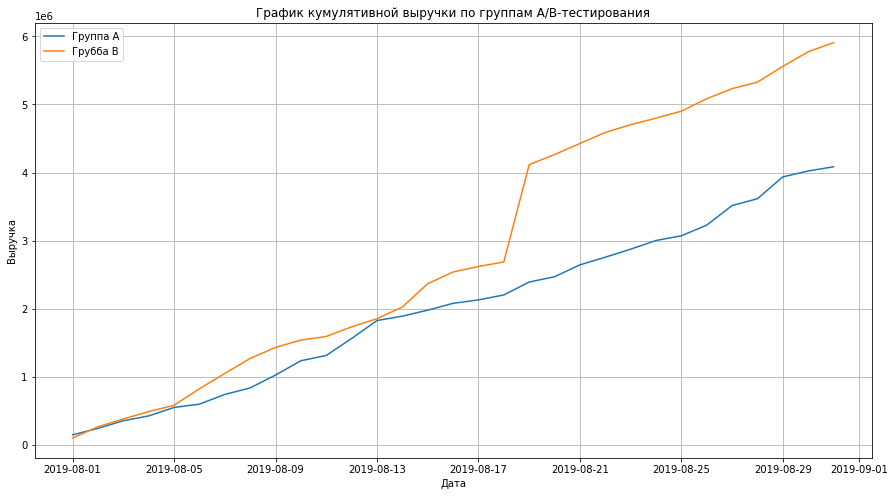

In [51]:
cumulativeRevenueA = cumulativeData[cumulativeData['group']=='A'][['date','revenue', 'orders']] 
# Объявим переменную, в которую сохраним данные о датах, выручке и числе заказов в группе А
cumulativeRevenueB = cumulativeData[cumulativeData['group']=='B'][['date','revenue', 'orders']] 
# Объявим переменную, в которую сохраним данные о датах, выручке и числе заказов в группе B

plt.figure(figsize=(15,8))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue'], label='B')
# Построим график
plt.title('График кумулятивной выручки по группам A/B-тестирования')
plt.xlabel('Дата')
plt.ylabel('Выручка')
plt.legend(['Группа А', 'Грубба B'])
plt.grid()
plt.show()

По графику видно следующее:
* Группа B имеет бОльшие темпы роста и лидирует на всем периоде
* Выручка растёт в обеих группах на протяжение всего теста
* 18 августа произошел резкий рост, это могло произойти по двум причинам: в этот день было много заказов или в этой группе был совершен слишком большой заказ

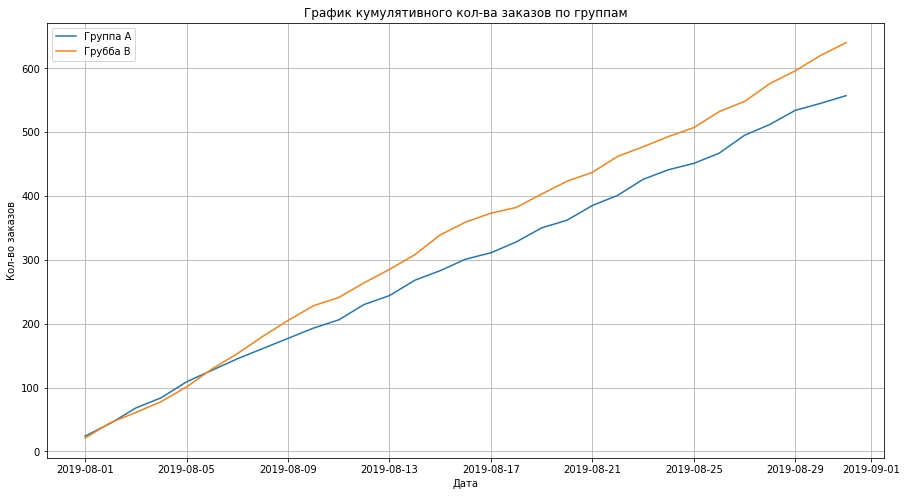

In [58]:
plt.figure(figsize=(15,8))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['orders'], label='B') 


plt.title('График кумулятивного кол-ва заказов по группам')
plt.xlabel('Дата')
plt.ylabel('Кол-во заказов') 
plt.legend(['Группа А', 'Грубба B'])
plt.grid()
plt.show()

График с количеством заказов идет плавно, значит дело не в количестве заказов а в объеме одного или нескольких заказов.

### Построение графика кумулятивного среднего чека по группам 

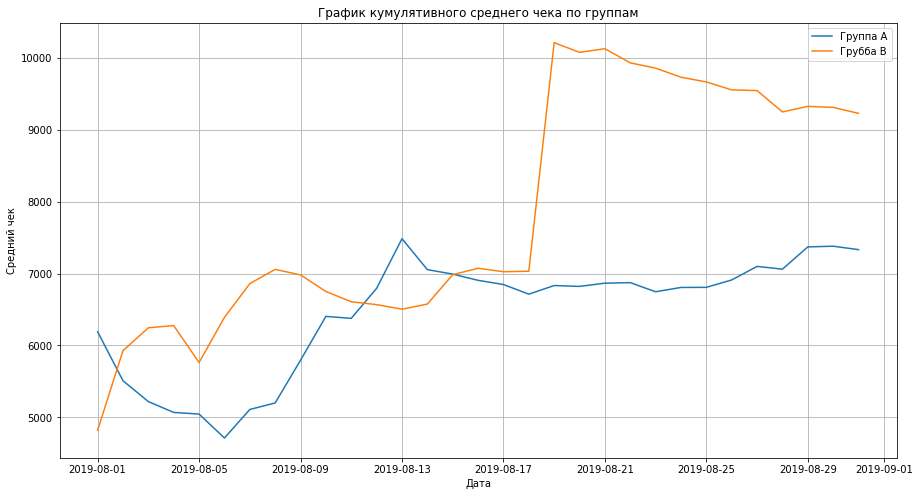

In [60]:
plt.figure(figsize=(15,8))
plt.plot(cumulativeRevenueA['date'], cumulativeRevenueA['revenue']/cumulativeRevenueA['orders'], label='A')
plt.plot(cumulativeRevenueB['date'], cumulativeRevenueB['revenue']/cumulativeRevenueB['orders'], label='B')

plt.title('График кумулятивного среднего чека по группам')
plt.xlabel('Дата')
plt.ylabel('Средний чек')
plt.legend(['Группа А', 'Грубба B'])
plt.grid()
plt.show()

По графику видно следующее:
* в первой половине эксперимента данные видут себя не стабильно
* на графике группы B виден аномальный рост величины среднего чека
* к концу эксперимента видим что средний чек группы B выше чем группы А, но у группы A наблюдается восходящая тенденция, а у группы B нисходящая.

### Построение графика относительного изменения кумулятивного среднего чека группы B к группе A

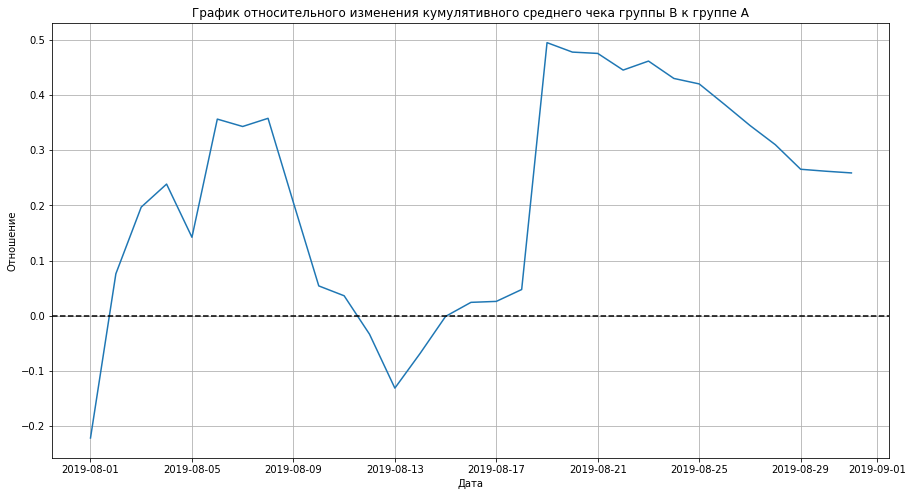

In [66]:
mergedcumulativeRevenue = cumulativeRevenueA.merge(
    cumulativeRevenueB, left_on='date', right_on='date', how='left', suffixes=['A', 'B'] # Объединим таблицы cumulativeRevenueA и cumulativeRevenueB
)
# собираем данные в одном датафрейме

plt.figure(figsize=(15,8))
plt.plot(mergedcumulativeRevenue['date'],
         (mergedcumulativeRevenue['revenueB']/mergedcumulativeRevenue['ordersB'])/
         (mergedcumulativeRevenue['revenueA']/mergedcumulativeRevenue['ordersA'])-1)

plt.axhline(y=0, color='black', linestyle='--') 

plt.title('График относительного изменения кумулятивного среднего чека группы B к группе A')
plt.xlabel('Дата')
plt.ylabel('Отношение') 
plt.grid()
plt.show()

На графике мы можем видеть, что изменения кумулятивного среднего чека группы В к группе А достаточно резкие, это может значить, что именно в пиковый дни на графике, были сделаны анамально дорогие заказы.

### Построение графика кумулятивного среднего количества заказов на посетителя по группам

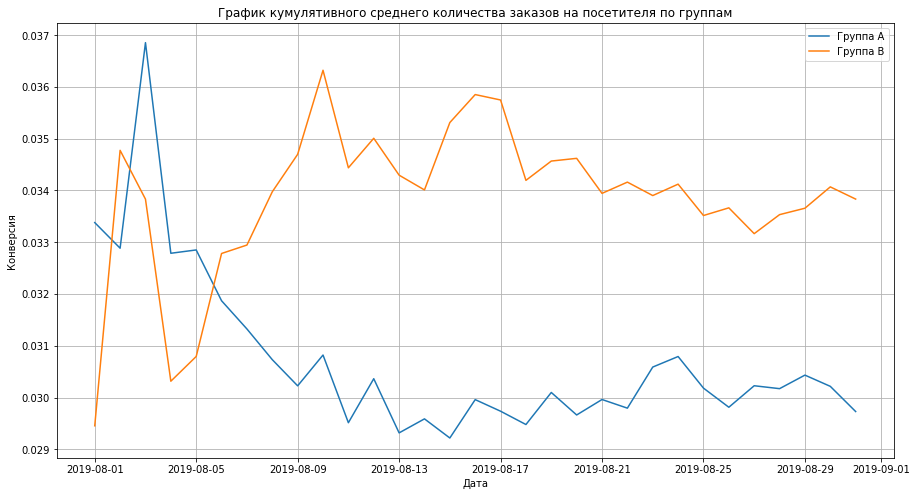

In [70]:
cumulativeData['conversion'] = cumulativeData['orders']/cumulativeData['visitors'] 
# добавим столбец 'conversion' c отношением числа заказов к количеству пользователей в указанной группе в указанный день.

cumulativeDataA = cumulativeData[cumulativeData['group']=='A'] # создадим переменную с данными о заказах группы А
cumulativeDataB = cumulativeData[cumulativeData['group']=='B'] # создадим переменную с данными о заказах группы В

plt.figure(figsize=(15,8))
plt.plot(cumulativeDataA['date'], cumulativeDataA['conversion'], label='A')
plt.plot(cumulativeDataB['date'], cumulativeDataB['conversion'], label='B')
plt.title('График кумулятивного среднего количества заказов на посетителя по группам')
plt.xlabel('Дата')
plt.ylabel('Конверсия') 
plt.legend(['Группа А', 'Группа B']) 
plt.grid()
plt.show()

Из графика можно сделать вывод что:
* в начале теста среднее количество заказов группы А выше, после чего она снизилась и зафиксировалась на одном уровне, у группы В наоборот
* на протяжении всего эксперимента, начиная с 6 августа, среднея конверсия группы В выше, чем у группы А

### Построение графика относительного изменения кумулятивной конверсии группы B к группе A

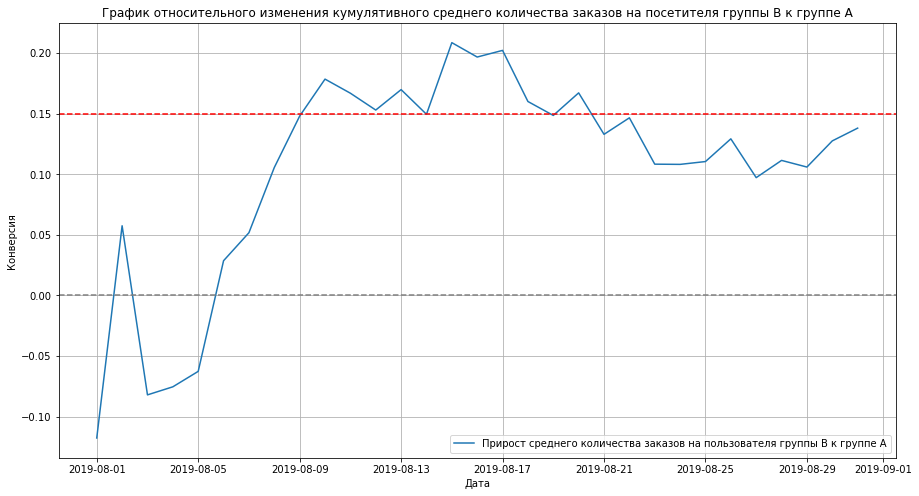

In [73]:
mergedcumulativeConversions = cumulativeDataA[['date','conversion']].merge(
    cumulativeDataB[['date','conversion']], left_on='date', right_on='date', how='left', suffixes=['A', 'B']
) # Объединим таблицы cumulativeDataA и cumulativeDataB

plt.figure(figsize=(15,8))
plt.plot(
    mergedcumulativeConversions['date'], mergedcumulativeConversions['conversionB']/
    mergedcumulativeConversions['conversionA']-1, label="Прирост среднего количества заказов на пользователя группы B к группе A")

plt.legend()
plt.axhline(y=0, color='grey', linestyle='--')
plt.axhline(y=0.15, color='red', linestyle='--')
plt.title('График относительного изменения кумулятивного среднего количества заказов на посетителя группы B к группе A')
plt.ylabel('Конверсия') 
plt.xlabel('Дата') 
plt.grid()
plt.show()

На графике видим, что среднее количество заказов на пользователя группы В показывает себя лучше, достигая прироста в 15-20 процентов относительно группы А. К концу теста прирост составил 14% с тенденцией роста.

### Построение точечного графика количества заказов по пользователям

In [75]:
orders_by_users = orders.groupby(
    'visitor_id', as_index=False).agg({'transaction_id':'nunique'}).rename(columns={'transaction_id':'orders'})
display(orders_by_users.sort_values(by='orders', ascending=False).head(10))

,visitor_id,orders
1023,4256040402,11
591,2458001652,11
569,2378935119,9
487,2038680547,8
44,199603092,5
744,3062433592,5
55,237748145,5
917,3803269165,5
299,1230306981,5
897,3717692402,5


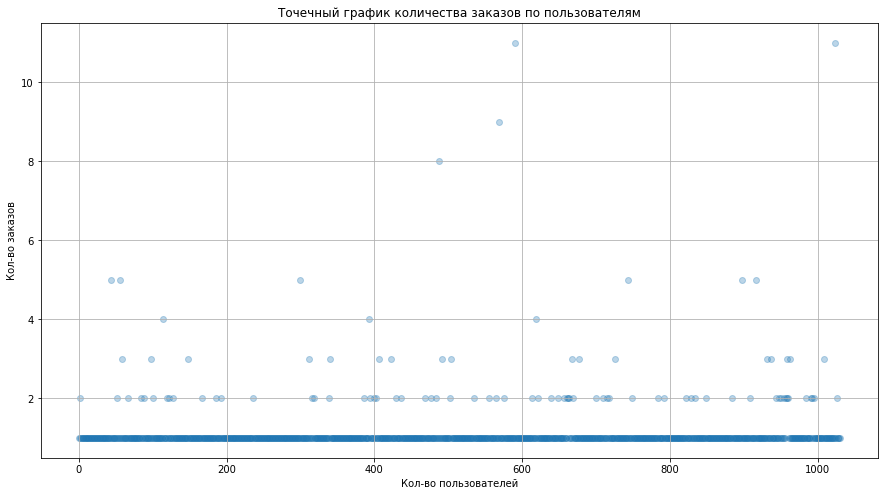

In [76]:
x_values = pd.Series(range(0,len(orders_by_users['orders'])))

plt.figure(figsize=(15,8))
plt.scatter(x_values, orders_by_users['orders'], alpha=0.3)
plt.title('Точечный график количества заказов по пользователям')
plt.xlabel('Кол-во пользователей')
plt.ylabel('Кол-во заказов')
plt.grid()
plt.show()

На графике видим что у большиснтва пользователей 1-2 заказа, пользователей с 3 заказами еще достаточнов весомое количество, но вот пользователей которые оформили более 3-х заказов уже мало.

### Подсчёт 95-го и 99-го перцентилей количества заказов на пользователя.

In [77]:
print(np.percentile(orders_by_users['orders'], [95, 99])) 

[2. 4.]


Получаем следующий результат:
* не более 5 % совершили больше 2-ух заказов
* не более 1 % совершили больше 4-ёх заказов

Устанавливаем границу по колличеству заказов на пользователя в 3 шт., заключим её в переменную.


In [78]:
too_much_orders = 3 

### Построение точечного графика стоимостей заказов 

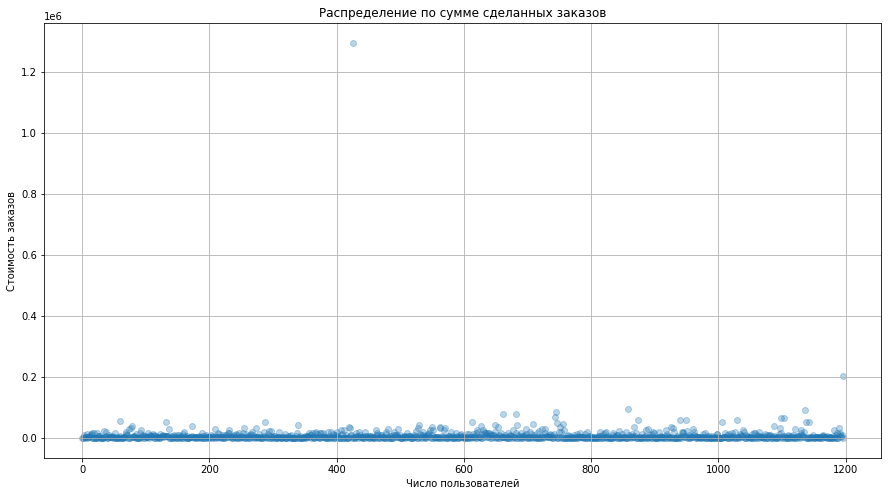

In [81]:
x_values = pd.Series(range(0,len(orders['revenue'])))

plt.figure(figsize=(15,8))
plt.scatter(x_values, orders['revenue'], alpha=0.3)
plt.title('Распределение по сумме сделанных заказов')
plt.xlabel('Число пользователей')
plt.ylabel('Стоимость заказов')
plt.grid()
plt.show()

Видно что один заказ сильно выбивается. Ограничиваем максимальное значение стоимости 100000 чтобы наглядней видеть распределение большинства.

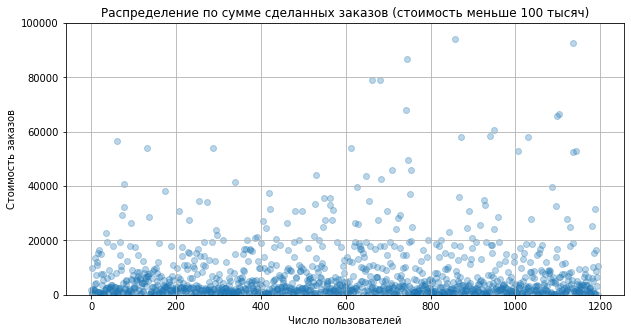

In [83]:
plt.figure(figsize=(10,5))
plt.scatter(x_values, orders['revenue'], alpha=0.3)
plt.title('Распределение по сумме сделанных заказов (стоимость меньше 100 тысяч)')
plt.ylim(0, 100000)
plt.xlabel('Число пользователей')
plt.ylabel('Стоимость заказов')
plt.grid()
plt.show()

Видим, что основная часть пользователей совершает заказы стоимостью менее 20000.

### Подсчёт 95-го и 99-го перцентилей стоимости заказа.

In [84]:
print(np.percentile(orders['revenue'], [95, 99])) 

[28000.  58233.2]


Получаем следующий результат:
* не более 5 % заказов стомостью более 28000 рублей 
* не более 1 % заказов стомостью более 58000 рублей  

Устанавливаем границу по сумме заказа в 30000 рублей, добавим её в переменную: 

In [86]:
too_expensive_order  = 30000

### Подсчёт статистической значимости различий в конверсии между группами по «сырым» данным 

Формулировка гипотез.

**Нулевая гипотеза:** Различий в конверсии между группами нет (статистическая значимость не значительна и сделать вывод о различии нельзя).

**Альтернативная гипотеза:** Различия в конверсиях между группами есть (между выборками имеется статистическая значимость).

**Коэффициент альфа:** 0.05

In [93]:
visitorsADaily = visitors[visitors['group'] == 'A'][['date', 'visitors']]
visitorsADaily.columns = ['date', 'visitorsPerDateA']

visitorsACummulative = visitorsADaily.apply(
    lambda x: visitorsADaily[visitorsADaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateA': 'sum'}
    ),
    axis=1,
)
visitorsACummulative.columns = ['date', 'visitorsCummulativeA']

visitorsBDaily = visitors[visitors['group'] == 'B'][['date', 'visitors']]
visitorsBDaily.columns = ['date', 'visitorsPerDateB']

visitorsBCummulative = visitorsBDaily.apply(
    lambda x: visitorsBDaily[visitorsBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'visitorsPerDateB': 'sum'}
    ),
    axis=1,
)
visitorsBCummulative.columns = ['date', 'visitorsCummulativeB']

ordersADaily = (
    orders[orders['group'] == 'A'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
ordersADaily.columns = ['date', 'ordersPerDateA', 'revenuePerDateA']

ordersACummulative = ordersADaily.apply(
    lambda x: ordersADaily[ordersADaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateA': 'sum', 'revenuePerDateA': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersACummulative.columns = [
    'date',
    'ordersCummulativeA',
    'revenueCummulativeA',
]

ordersBDaily = (
    orders[orders['group'] == 'B'][['date', 'transaction_id', 'visitor_id', 'revenue']]
    .groupby('date', as_index=False)
    .agg({'transaction_id': pd.Series.nunique, 'revenue': 'sum'})
)
ordersBDaily.columns = ['date', 'ordersPerDateB', 'revenuePerDateB']

ordersBCummulative = ordersBDaily.apply(
    lambda x: ordersBDaily[ordersBDaily['date'] <= x['date']].agg(
        {'date': 'max', 'ordersPerDateB': 'sum', 'revenuePerDateB': 'sum'}
    ),
    axis=1,
).sort_values(by=['date'])
ordersBCummulative.columns = [
    'date',
    'ordersCummulativeB',
    'revenueCummulativeB',
]

cummulative = (
    ordersADaily.merge(
        ordersBDaily, left_on='date', right_on='date', how='left'
    )
    .merge(ordersACummulative, left_on='date', right_on='date', how='left')
    .merge(ordersBCummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsADaily, left_on='date', right_on='date', how='left')
    .merge(visitorsBDaily, left_on='date', right_on='date', how='left')
    .merge(visitorsACummulative, left_on='date', right_on='date', how='left')
    .merge(visitorsBCummulative, left_on='date', right_on='date', how='left')
)

ordersByUsersA = (
    orders[orders['group'] == 'A']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersA.columns = ['userId', 'orders']

ordersByUsersB = (
    orders[orders['group'] == 'B']
    .groupby('visitor_id', as_index=False)
    .agg({'transaction_id': pd.Series.nunique})
)
ordersByUsersB.columns = ['userId', 'orders']

sampleA = pd.concat(
    [
        ordersByUsersA['orders'],
        pd.Series(
            0,
            index=np.arange(
                cummulative['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleB = pd.concat(
    [
        ordersByUsersB['orders'],
        pd.Series(
            0,
            index=np.arange(
                cummulative['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

In [94]:
display('Статистическая значимость:','{0:.3f}'.format(stats.mannwhitneyu(sampleA, sampleB)[1]))
display('Значение относительного прироста:','{0:.3f}'.format(sampleB.mean() / sampleA.mean() - 1))

'Статистическая значимость:'

'0.017'

'Значение относительного прироста:'

'0.138'

P-value значительно меньше 0.05, **не получилось подтвердить нулевую гипотезу.** Среднее количество заказов на пользователя в группе A не равно группе B (между выборками имеется статистическая значимость). Относительный прирост среднего группы В к группе А равен 13.8%. На следующих этапах посмотрим какое значения будут иметь данные без аномалий

### Подсчёт статистической значимости различий в среднем чеке заказа между группами по «сырым» данным

Формулировка гипотез.

**Нулевая гипотеза:** Различий в средних чеках между группами нет (статистическая значимость не значительна и сделать вывод о различии нельзя).

**Альтернативная гипотеза:** Различия в средних чеках между группами есть (между выборками имеется статистическая значимость).

**Коэффициент альфа:** 0.05

In [99]:
display('Статистическая значимость:','{0:.3f}'.format(stats.mannwhitneyu(orders[orders['group']=='A']['revenue'], orders[orders['group']=='B']['revenue'])[1]))
display('Значение относительного прироста:','{0:.3f}'.format(orders[orders['group']=='B']['revenue'].mean()/orders[orders['group']=='A']['revenue'].mean()-1)) 

'Статистическая значимость:'

'0.729'

'Значение относительного прироста:'

'0.259'

P-value значительно больше 0.05, **не получилось отвергнуть нулевую гипотезу.** Средний чек в группе A равен группе B (статистическая значимость не значительна и сделать вывод о различии нельзя). Относительный прирост среднего чека группы В к группе А равен 25,9%. Что было заметно на графиках ранее.

### Подсчёт статистической значимости различий в конверсии между группами по «очищенным» данным 

Формулировка гипотез.

**Нулевая гипотеза:** Различий в конверсии между группами нет (статистическая значимость не значительна и сделать вывод о различии нельзя).

**Альтернативная гипотеза:** Различия в конверсиях между группами есть (между выборками имеется статистическая значимость).

**Коэффициент альфа:** 0.05

Очистим данные от аномальных значений, ранее мы установили верхние границы в максимум 3 заказа на пользователя и на заказы не дороже 30 тысяч.

In [97]:
usersWithManyOrders = pd.concat(
    [
        ordersByUsersA[ordersByUsersA['orders'] > too_much_orders]['userId'],
        ordersByUsersB[ordersByUsersB['orders'] > too_much_orders]['userId'],
    ],
    axis=0,
)


usersWithExpensiveOrders = orders[orders['revenue'] > too_expensive_order]['visitor_id']
abnormalUsers = (
    pd.concat([usersWithManyOrders, usersWithExpensiveOrders], axis=0)
    .drop_duplicates()
    .sort_values()
)
sampleAFiltered = pd.concat(
    [
        ordersByUsersA[
            np.logical_not(ordersByUsersA['userId'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                cummulative['visitorsPerDateA'].sum() - len(ordersByUsersA['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
)

sampleBFiltered = pd.concat(
    [
        ordersByUsersB[
            np.logical_not(ordersByUsersB['userId'].isin(abnormalUsers))
        ]['orders'],
        pd.Series(
            0,
            index=np.arange(
                cummulative['visitorsPerDateB'].sum() - len(ordersByUsersB['orders'])
            ),
            name='orders',
        ),
    ],
    axis=0,
) 

In [100]:
display('Статистическая значимость:','{0:.3f}'.format(stats.mannwhitneyu(sampleAFiltered, sampleBFiltered)[1]))
display('Значение относительного прироста','{0:.3f}'.format(sampleBFiltered.mean()/sampleAFiltered.mean()-1)) 

'Статистическая значимость:'

'0.018'

'Значение относительного прироста'

'0.148'

Вывод такой же как в пункте 2.12, **не получилось подтвердить нулевую гипотезу.**

### Подсчёт статистической значимости различий в различий в среднем чеке заказа по «очищенным» данным 

Формулировка гипотез.

**Нулевая гипотеза:** Различий в средних чеках между группами нет (статистическая значимость не значительна и сделать вывод о различии нельзя).

**Альтернативная гипотеза:** Различия в средних чеках между группами есть (между выборками имеется статистическая значимость).

**Коэффициент альфа:** 0.05

In [102]:
display(
    'Статистическая значимость','{0:.3f}'.format(
        stats.mannwhitneyu(
            orders[
                np.logical_and(
                    orders['group'] == 'A',
                    np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
            orders[
                np.logical_and(
                    orders['group'] == 'B',
                    np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
                )
            ]['revenue'],
        )[1]
    )
)

display(
    'Значение относительного прироста','{0:.3f}'.format(
        orders[
            np.logical_and(
                orders['group'] == 'B',
                np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        / orders[
            np.logical_and(
                orders['group'] == 'A',
                np.logical_not(orders['visitor_id'].isin(abnormalUsers)),
            )
        ]['revenue'].mean()
        - 1
    )
)

'Статистическая значимость'

'0.958'

'Значение относительного прироста'

'-0.020'

Для "очищенных" данных статистическая занчимость средних чеков группы B и A, также равны, но стоит заметить, что абсолютные значения практически выровнились, отношение близко к единице.

## Решение по результатам теста

В ходе теста получилось подтвердить следующие гипотезы:
* И по сырым, и по очищенным данным видно что средняя конверсия группы В больше чем у группы А
* И по сырым, и по очищенным данным видно что средние чеки группы А и группы В равны

Несмотря на то что чисто номинально можно останавливать тест и фиксировать что результаты группы B более удовлетворительные, я бы советовал продолжать тестирование исходя из тенденций среднего чека. 